In [1]:
import sys
if '/disks/cosmodm/vdvuurst' not in sys.path:
    sys.path.append('/disks/cosmodm/vdvuurst')

import numpy as np
import h5py
from matplotlib import pyplot as plt
import os
from importlib import reload
import json
import ONEHALO
from tqdm import tqdm
from functions import *
from onehalo_plotter import *
format_plot()

There are 9216 function combinations


In [ ]:
def perturb_around_likelihood(L: float, params: np.array, log_likelihood_func: Callable[[np.array], float], single_gauss: bool = False) -> dict:
    """ Given a maximum from MCMC, perturb around this found maximum in small steps to estimate the error and refine the estimate.

    Args:
        L (float): Likelihood value at the best found parameter set
        params (np.array): Best found parameter set
        log_likelihood_func (function, optional): Log likelihood of the model. Defaults to mod_gaussian_log_likelihood.
        single_gauss (bool, optional): Controls whether we "turn off" the lambda parameter, i.e. fix it to 0.

    Returns:
        dict: dictionary of parameter values and error estimates
    """
    
    #TODO: fix for joint model, there will be more parameters and this is hardcoded to 3 parameters now

    param_steps = [1., 1., 0.1]  #NOTE: subject to change

    L_thresh = 1.01 * L #1%
    if not single_gauss:
        param_dict = {'sigma_1':params[0], 'sigma_2':params[1], 'lambda': params[2], 'errors':[[] for i in range(len(params))]}
        bounds, params = _perturb_params(params, log_likelihood_func)
            # param_down, params = _perturb_param(params, i, param_steps[i], L, L_thresh, dir = -1, log_likelihood_func = log_likelihood_func)
        for i in range(len(params)):
            param_down, param_up = bounds[i]
            param_dict['errors'][i] = [np.abs(params[i] - param_down), np.abs(params[i] - param_up)] # errors are the parameter differences

        return param_dict

    #TODO update to new form
    else:
        # If we do not use lambda and sigma2, only perturb for sigma1
        param_dict = {'sigma_1':params[0], 'sigma_2':params[1], 'lambda': 0., 'errors':[[] for i in range(len(params))]}

        param_up, params = _perturb_params(params, 0, param_steps[0], L, L_thresh, dir = 1, log_likelihood_func = log_likelihood_func)
        param_down, params = _perturb_params(params, 0, param_steps[0], L, L_thresh, dir = -1, log_likelihood_func = log_likelihood_func)

        param_dict['errors'][0] = [np.abs(params[0] - param_down), np.abs(params[0] - param_up)] # errors are the parameter differences
        param_dict['errors'][1] = [np.abs(params[1] - GLOBAL_PRIOR_RANGE[1][0]), np.abs(params[1] - GLOBAL_PRIOR_RANGE[1][1])] # sigma_2 over entire prior range
        param_dict['errors'][-1] = [0.,0.] # fix lambda at 0 with no error
        
        return param_dict

def _perturb_params(params: np.array, log_likelihood_func: Callable[[np.array], float]):
    """ Perturb parameter value, either upwards or downwards, and return parameter value when likelihood threshold is reached.

    Args:
        params (list or array): list or array containing the parameter values in order [sigma1, sigma2, lambda]
        param_idx (int): index pointing to the parameter to perturb in the params list
        step (float): Stepsize for parameter perturbation
        L (float): Likehood at the best point
        L_thresh (float): Threshold likelihood to reach.
        dir (int, optional): Whether to perturb the parameter upwards or downwards; 1 for upwards, -1 for downwards. Defaults to 1.
        log_likelihood_func (function, optional): Log likelihood of the model. Defaults to mod_gaussian_log_likelihood. NOTE that this is an L-maximizing function since it is negative numbers we want to be as near to 0 as possible!

    Returns:
        float: parameter value at the likelihood threshold #TODO update
    """
    # L_current = L
    # L_best = L
    # perturbed_params = np.copy(params)

    prior_ranges = GLOBAL_PRIOR_RANGE.copy()

    if None in GLOBAL_PRIOR_RANGE[0]: # sigma_1
        prior_ranges[0][0] = params[1] 
    
    if None in GLOBAL_PRIOR_RANGE[1]: #sigma_2
        prior_ranges[1][1] = params[0]

    #TODO change for single gaussian
    opt_params = minimize(lambda x: -log_likelihood_func(x), x0 = params, bounds = prior_ranges).x
    L_best = log_likelihood_func(opt_params)

    #TODO: change to an actual error measurement
    # prior_idx = 0 if dir == -1 else 1
    # return prior_ranges, opt_params

    perturb_sigma1 = lambda x: (log_likelihood_func((x, opt_params[1], opt_params[2])) / L_best) - 1.01
    perturb_sigma2 = lambda x: (log_likelihood_func((opt_params[0], x, opt_params[2])) / L_best) - 1.01
    perturb_lambda = lambda x: (log_likelihood_func((opt_params[0], opt_params[1], x)) / L_best) - 1.01

    #TODO: this now takes the entire prior range if even ONE of the directions raises a runtime error or value_error, so double the try/excepts
    #NOTE runtime error means it did not converge, value error means that the signage of the function didnt change in the interval so there was no root in it
    try:
        sigma1_bounds = [brentq(perturb_sigma1, GLOBAL_PRIOR_RANGE[0][0], opt_params[0]), brentq(perturb_sigma1, opt_params[0],GLOBAL_PRIOR_RANGE[0][1])]
    except (RuntimeError, ValueError):
        sigma1_bounds = GLOBAL_PRIOR_RANGE[0]
    try:
        sigma2_bounds = [brentq(perturb_sigma2, GLOBAL_PRIOR_RANGE[1][0], opt_params[1]), brentq(perturb_sigma2, opt_params[1], GLOBAL_PRIOR_RANGE[1][1])]
    except (RuntimeError, ValueError):
        sigma2_bounds = GLOBAL_PRIOR_RANGE[1]
    try:
        lambda_bounds = [brentq(perturb_lambda, 0, opt_params[2]), brentq(perturb_lambda, opt_params[2], 0.5)]
    except (RuntimeError, ValueError):
        lambda_bounds = GLOBAL_PRIOR_RANGE[2]

    param_bounds = [sigma1_bounds, sigma2_bounds, lambda_bounds]

    return param_bounds, opt_params


In [32]:
with h5py.File('/disks/cosmodm/vdvuurst/data/OneHalo_0.5dex/M_12.5-13.0/Rvir/r_0.30-0.39.hdf5') as handle:
    data_low_error = handle['rel_vels'][:]

def read_params_from_dict(paramdict):
    return np.array([paramdict['sigma_1'], paramdict['sigma_2'], paramdict['lambda']])

with open('/disks/cosmodm/vdvuurst/data/OneHalo_param_fits/emcee/M_12.5-13.0/Rvir/r_0.30-0.39.json') as pfile:
    emcee_results_dict_low_error = json.load(pfile)

best_params_low_error = read_params_from_dict(emcee_results_dict_low_error)
best_likelihood_low_error = emcee_results_dict_low_error['likelihood']

ll_func_low_error = lambda x: mod_gaussian_log_likelihood(x, data_low_error, False, False)
# param_dict_low_error = perturb_around_likelihood(best_likelihood_low_error, best_params_low_error, ll_func_low_error, single_gauss =False)



with h5py.File('/disks/cosmodm/vdvuurst/data/OneHalo_0.5dex/M_14.5-15.0/Rvir/r_1.21-1.36.hdf5') as handle:
    data_high_error = handle['rel_vels'][:]

with open('/disks/cosmodm/vdvuurst/data/OneHalo_param_fits/emcee/M_14.5-15.0/Rvir/r_1.21-1.36.json') as pfile:
    emcee_results_dict_high_error = json.load(pfile)

best_params_high_error = read_params_from_dict(emcee_results_dict_high_error)
best_likelihood_high_error = emcee_results_dict_high_error['likelihood']

ll_func_high_error = lambda x: mod_gaussian_log_likelihood(x, data_high_error, False, False)
# param_dict_high_error = perturb_around_likelihood(best_likelihood_high_error, best_params_high_error, ll_func_high_error, single_gauss =False)

In [155]:
def sample_for_brent(params, found_likelihood, log_likelihood_func, single_gauss = False):
    if single_gauss:
        step_sizes = [100.]
    else:
        step_sizes = [100., 100., 0.1] # high valued steps
    Lthresh = 1.01 * found_likelihood

    bounds = [[] for _ in range(len(step_sizes))]

    for param_idx,step in enumerate(step_sizes):
        param_insert = params.copy()
        current_param_value = params[param_idx]
        # perturbation_of_parameter = np.arange(params[param_idx] - 100*step, params[param_idx] + 100*step, step = step).reshape(200,1)
        # step up
        prior_flag = False
        Lcurrent = found_likelihood

        while Lcurrent < Lthresh:
            current_param_value += step
            if current_param_value >= GLOBAL_PRIOR_RANGE[param_idx][1]:
                # current_param_value -= step # step back to previous
                prior_flag = True
                break

            np.put(param_insert, param_idx, current_param_value)
            Lcurrent = log_likelihood_func(param_insert)

        param_up = current_param_value if not prior_flag else GLOBAL_PRIOR_RANGE[param_idx][1]

        # step down, so reset some stuff
        prior_flag = False
        np.put(param_insert, param_idx, params[param_idx])
        current_param_value = params[param_idx]
        Lcurrent = found_likelihood
        while Lcurrent < Lthresh:
            current_param_value -= step
            if current_param_value <= GLOBAL_PRIOR_RANGE[param_idx][0]:
                # current_param_value -= step # step back to previous
                prior_flag = True
                break

            np.put(param_insert, param_idx, current_param_value)
            Lcurrent = log_likelihood_func(param_insert)

        param_down = current_param_value if not prior_flag else GLOBAL_PRIOR_RANGE[param_idx][0]

        bounds[param_idx] = [param_down, param_up]
    
    return bounds

sample_for_brent(best_params_low_error, -1*best_likelihood_low_error, lambda x: -1*ll_func_low_error(x), single_gauss=False)

[[np.float64(60.544267993789276), np.float64(260.5442679937893)],
 [1.0, 1500.0],
 [0.0, np.float64(0.10028084242504773)]]

In [ ]:
def _perturb_params(params: np.array, log_likelihood_func: Callable[[np.array], float], single_gauss = False):
    """ Perturb parameter value, either upwards or downwards, and return parameter value when likelihood threshold is reached.

    Args:
        params (list or array): list or array containing the parameter values in order [sigma1, sigma2, lambda]
        param_idx (int): index pointing to the parameter to perturb in the params list
        step (float): Stepsize for parameter perturbation
        L (float): Likehood at the best point
        L_thresh (float): Threshold likelihood to reach.
        dir (int, optional): Whether to perturb the parameter upwards or downwards; 1 for upwards, -1 for downwards. Defaults to 1.
        log_likelihood_func (function, optional): Log likelihood of the model. Defaults to mod_gaussian_log_likelihood. NOTE that this is an L-maximizing function since it is negative numbers we want to be as near to 0 as possible!

    Returns:
        float: parameter value at the likelihood threshold #TODO update
    """
    prior_ranges = GLOBAL_PRIOR_RANGE.copy()

    if None in GLOBAL_PRIOR_RANGE[0]: # sigma_1
        prior_ranges[0][0] = params[1] 
    
    if None in GLOBAL_PRIOR_RANGE[1]: #sigma_2
        prior_ranges[1][1] = params[0]

    # we need the negative of the function we put in so that we can minimize
    ll_func_for_minimize = lambda x: -log_likelihood_func(x)
    opt_params = minimize(ll_func_for_minimize, x0 = params, bounds = prior_ranges).x
    L_best = log_likelihood_func(opt_params)

    # function which perturb only 1 parameter at a time, need to do it like this because the argument position changes
    perturb_sigma1 = lambda x: (log_likelihood_func((x, opt_params[1], opt_params[2])) - (1.01 * L_best))
    perturb_sigma2 = lambda x: (log_likelihood_func((opt_params[0], x, opt_params[2])) - (1.01 * L_best))
    perturb_lambda = lambda x: (log_likelihood_func((opt_params[0], opt_params[1], x)) - (1.01 * L_best))
    perturb_funcs = [perturb_sigma1, perturb_sigma2, perturb_lambda]

    # get the bounds for the root finder by taking large samples. note that this is actually the bottleneck of the code
    brent_bounds = sample_for_brent(opt_params, -1*L_best, ll_func_for_minimize, single_gauss = single_gauss)

    param_bounds = [[] for _ in range(len(params))]

    # NOTE runtime error means it did not converge, value error means that the signage of the function 
    # didnt change in the interval so there was no root in it    
    if not single_gauss:
        for param_idx in range(len(params)):
            try:
                lower_bound = brentq(perturb_funcs[param_idx], brent_bounds[param_idx][0], opt_params[param_idx])
            except (RuntimeError, ValueError):
                lower_bound = GLOBAL_PRIOR_RANGE[param_idx][0]
            try:
                upper_bound = brentq(perturb_funcs[param_idx], opt_params[param_idx], brent_bounds[param_idx][1])
            except (RuntimeError, ValueError):
                upper_bound = GLOBAL_PRIOR_RANGE[param_idx][1]
            
            param_bounds[param_idx] = [lower_bound, upper_bound]

    #TODO: single_gauss will not work for joint models, do we want it to?
    else:
        # sigma_1 needs this root-finding optimization
        try:
            lower_bound = brentq(perturb_funcs[0], brent_bounds[0][0], opt_params[0])
        except (RuntimeError, ValueError):
            lower_bound = GLOBAL_PRIOR_RANGE[0][0]
        try:
            upper_bound = brentq(perturb_funcs[0], opt_params[0], brent_bounds[0][1])
        except (RuntimeError, ValueError):
            upper_bound = GLOBAL_PRIOR_RANGE[0][1]
        
        param_bounds[0] = [lower_bound, upper_bound]
        
        # the other two parameters do not need it and just get the prior range as errors
        for param_idx in range(1,len(params)):
            param_bounds[param_idx] = GLOBAL_PRIOR_RANGE[param_idx]

    return param_bounds, opt_params

def perturb_around_likelihood(L: float, params: np.array, log_likelihood_func: Callable[[np.array], float], single_gauss: bool = False) -> dict:
    """ Given a maximum from MCMC, perturb around this found maximum in small steps to estimate the error and refine the estimate.

    Args:
        L (float): Likelihood value at the best found parameter set
        params (np.array): Best found parameter set
        log_likelihood_func (function, optional): Log likelihood of the model. Defaults to mod_gaussian_log_likelihood.
        single_gauss (bool, optional): Controls whether we "turn off" the lambda parameter, i.e. fix it to 0.

    Returns:
        dict: dictionary of parameter values and error estimates
    """
    
    #TODO: fix for joint model, there will be more parameters and this is hardcoded to 3 parameters now
    # ^that is gonna suck so fucking much

    bounds, best_params = _perturb_params(params, log_likelihood_func, single_gauss = single_gauss)
    param_dict = {'sigma_1':best_params[0], 'sigma_2':best_params[1], 'lambda': best_params[2], 'errors':[[] for i in range(len(best_params))]}

    for i in range(len(best_params)):
        param_down, param_up = bounds[i]
        param_dict['errors'][i] = [np.abs(best_params[i] - param_down), np.abs(best_params[i] - param_up)] # errors are the parameter differences

    return param_dict

In [157]:
param_dict_low_error = perturb_around_likelihood(best_likelihood_low_error, best_params_low_error, ll_func_low_error, single_gauss =False)
param_dict_high_error = perturb_around_likelihood(best_likelihood_high_error, best_params_high_error, ll_func_high_error, single_gauss =False)

print(param_dict_low_error) 
print(param_dict_low_error_OLD)

{'sigma_1': np.float64(161.29530005445014), 'sigma_2': np.float64(532.5505993131001), 'lambda': np.float64(0.00025143061068324635), 'errors': [[np.float64(34.171085531926536), np.float64(52.14439373879463)], [np.float64(531.5505993131001), np.float64(967.4494006868999)], [np.float64(0.00025143061068324635), np.float64(0.054673687627693514)]]}
{'sigma_1': np.float64(160.54426799378928), 'sigma_2': np.float64(532.5488527265495), 'lambda': np.float64(0.00028084242504771567), 'errors': [[np.float64(34.45339706541313), np.float64(51.885598262247896)], [np.float64(545.5488527265495), np.float64(953.4511472734505)], [np.float64(0.00028084242504771567), np.float64(0.05170176686411123)]]}


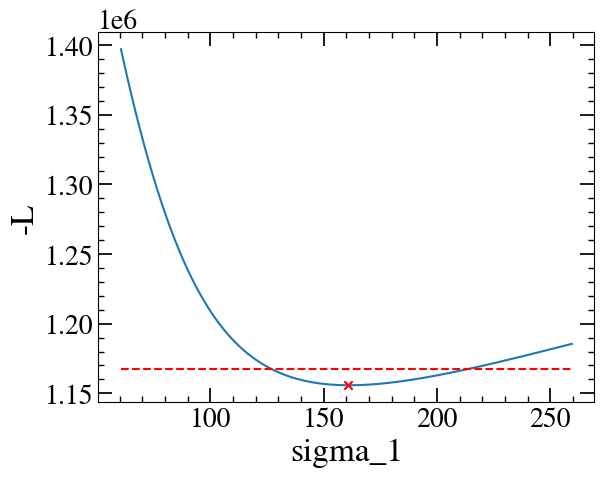

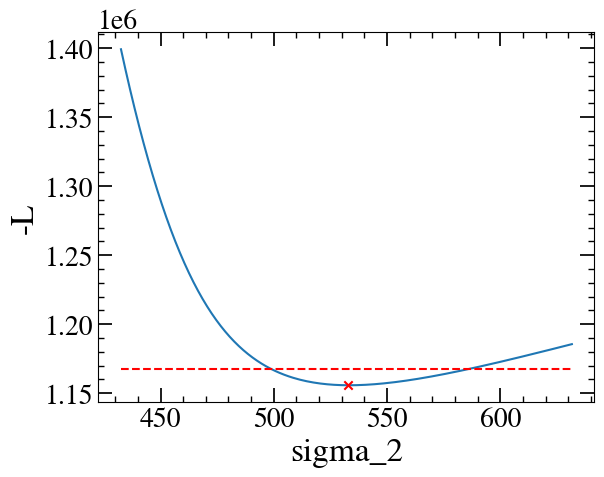

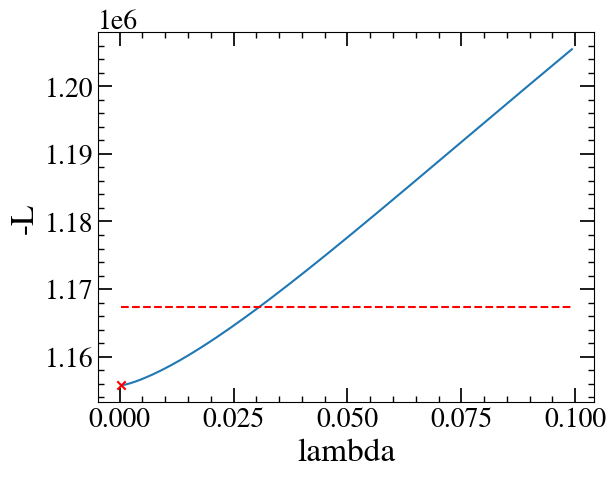

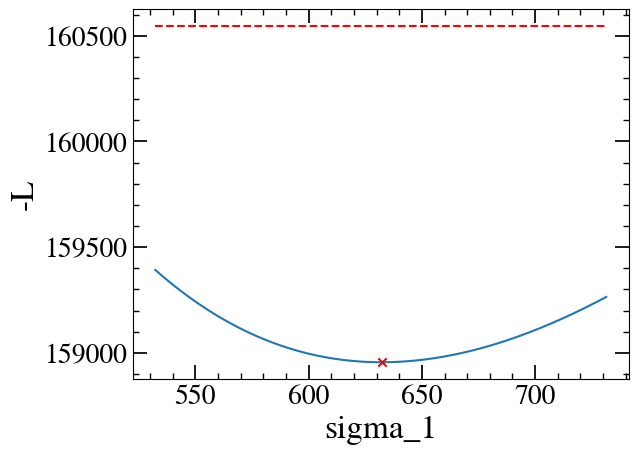

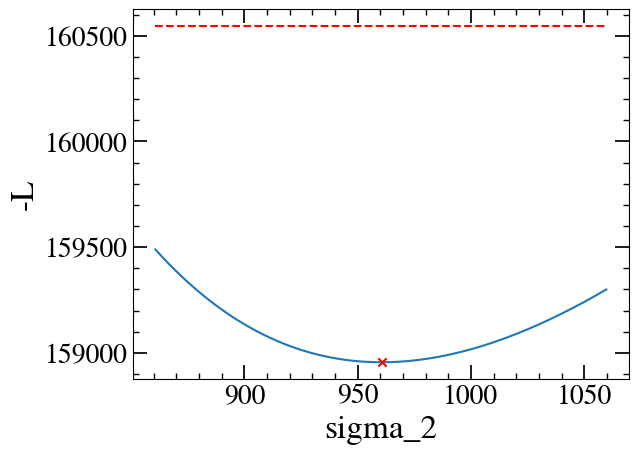

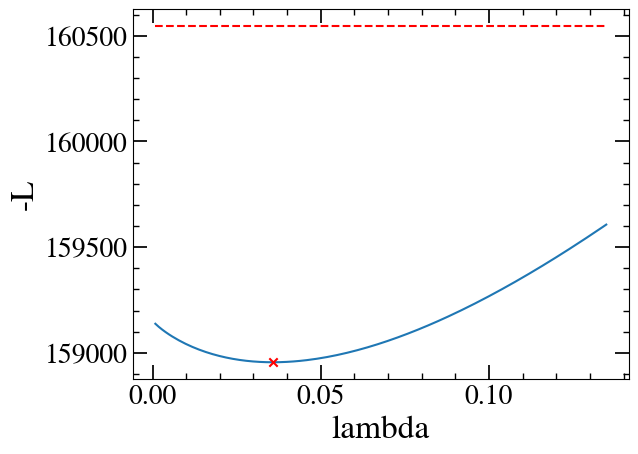

In [61]:
def investigate_likelihood_landscape(params, found_likelihood, log_likelihood_func, step_sizes = [1., 1., 0.001]):
        # params = read_params_from_dict(param_dict)
        param_names = ['sigma_1', 'sigma_2', 'lambda']
        perturbation = np.full((200,3), params)
        for param_idx,step in enumerate(step_sizes):

            perturbation_of_parameter = np.arange(params[param_idx] - 100*step, params[param_idx] + 100*step, step = step).reshape(200,1)
            minp, maxp = perturbation_of_parameter[0], perturbation_of_parameter[-1]
            np.put_along_axis(perturbation, np.full((200,1), param_idx), perturbation_of_parameter, axis = 1)
            likelihoods = np.apply_along_axis(log_likelihood_func, axis = 1, arr = perturbation)

            # new_best_arg = np.nanargmin(likelihoods)
            
            plt.figure()
            plt.plot(perturbation_of_parameter, likelihoods)
            plt.scatter(params[param_idx], found_likelihood, marker ='x', color ='red', label = 'initial', zorder = 10)
            # plt.scatter(perturbation_of_parameter[new_best_arg], likelihoods[new_best_arg], marker ='s', color = 'black', label = 'new best', zorder = 9)
            
            relevant_param_values = perturbation_of_parameter[np.isfinite(likelihoods)]
            plt.hlines(1.01 * found_likelihood, relevant_param_values[0], relevant_param_values[-1], linestyles='--', label = 'Lthresh', colors = 'red')
            
            plt.xlabel(param_names[param_idx])
            plt.ylabel('-L')
            # plt.legend()
            plt.show()
        
investigate_likelihood_landscape(best_params_low_error, best_likelihood_low_error*-1, lambda x: -1*ll_func_low_error(x))
investigate_likelihood_landscape(best_params_high_error, best_likelihood_high_error*-1, lambda x: -1*ll_func_high_error(x))

### The old method for comparison

In [ ]:
def _perturb_param_OLD(params: np.array, param_idx: int, step: float, L: float, L_thresh:float, dir: int, log_likelihood_func: Callable[[np.array], float]):
    """ Perturb parameter value, either upwards or downwards, and return parameter value when likelihood threshold is reached.

    Args:
        params (list or array): list or array containing the parameter values in order [sigma1, sigma2, lambda]
        param_idx (int): index pointing to the parameter to perturb in the params list
        step (float): Stepsize for parameter perturbation
        L (float): Likehood at the best point
        L_thresh (float): Threshold likelihood to reach.
        dir (int, optional): Whether to perturb the parameter upwards or downwards; 1 for upwards, -1 for downwards. Defaults to 1.
        log_likelihood_func (function, optional): Log likelihood of the model. Defaults to mod_gaussian_log_likelihood.

    Returns:
        float: parameter value at the likelihood threshold
    """
    L_current = L
    L_best = L
    perturbed_params = np.copy(params)

    prior_ranges = GLOBAL_PRIOR_RANGE.copy()

    if None in GLOBAL_PRIOR_RANGE[0]: # sigma_1
        prior_ranges[0][0] = params[1] 
    
    if None in GLOBAL_PRIOR_RANGE[1]: #sigma_2
        prior_ranges[1][1] = params[0]

    while L_current >= L_thresh:
        # Save previous value
        previous_param_value = perturbed_params[param_idx]
        L_previous = L_current
        # Step parameter
        perturbed_params[param_idx] += dir * step
        L_current = log_likelihood_func(perturbed_params)

        if not np.isfinite(L_current):
            # Assume the previous step was the best we could get within prior range
            # so return the relevant prior bound as the value
            prior_idx = 0 if dir == -1 else 1
            return prior_ranges[param_idx][prior_idx], params

        # It might be that we step further into a maximum, in that case update the likelihood and parameter values accordingly
        if L_current > L_best:
            L_best = L_current
            L_thresh = 1.01 * L_best # so that we know to perturb around this new maximum
            params = np.copy(perturbed_params)
        

            ##BELOW: when this works it is really nice, but it might take VERY long
            # newstep = step
            # perturbed_params[param_idx] = previous_param_value # reset
            # # take succesively smaller steps until L_current is finite again
            # while not np.isfinite(L_current):
            #     newstep *= 0.5
            #     perturbed_params[param_idx] += dir * newstep
            #     L_current = log_likelihood_func(perturbed_params)
            
            # step = newstep # in case we need to continue, 
            # don't be guaranteed to make the same mistake of overstepping to inf

    # thresh is not precisely halfway between the points, 
    # this is more accurate but still assumes linearity
    y = L_current - L_thresh
    x = L_thresh - L_previous
    a = (y + x) / (perturbed_params[param_idx] - previous_param_value)
    b = L_thresh - x - a * previous_param_value
    param_bound = (L_thresh - b) / a

    return param_bound, params

def perturb_around_likelihood_OLD(L: float, params: np.array, log_likelihood_func: Callable[[np.array], float], single_gauss: bool = False) -> dict:
    """ Given a maximum from MCMC, perturb around this found maximum in small steps to estimate the error and refine the estimate.

    Args:
        L (float): Likelihood value at the best found parameter set
        params (np.array): Best found parameter set
        log_likelihood_func (function, optional): Log likelihood of the model. Defaults to mod_gaussian_log_likelihood.
        single_gauss (bool, optional): Controls whether we "turn off" the lambda parameter, i.e. fix it to 0.

    Returns:
        dict: dictionary of parameter values and error estimates
    """
    
    #TODO: fix for joint model, there will be more parameters and this is hardcoded to 3 parameters now

    param_steps = [1., 1., 0.1]  #NOTE: subject to change

    L_thresh = 1.01 * L #1%
    if not single_gauss:
        param_dict = {'sigma_1':params[0], 'sigma_2':params[1], 'lambda': params[2], 'errors':[[] for i in range(len(params))]}
        for i in range(len(params)):
            param_up, params = _perturb_param_OLD(params, i, param_steps[i], L, L_thresh, dir = 1, log_likelihood_func = log_likelihood_func)
            param_down, params = _perturb_param_OLD(params, i, param_steps[i], L, L_thresh, dir = -1, log_likelihood_func = log_likelihood_func)

            param_dict['errors'][i] = [np.abs(params[i] - param_down), np.abs(params[i] - param_up)] # errors are the parameter differences

        return param_dict

    else:
        # If we do not use lambda and sigma2, only perturb for sigma1
        param_dict = {'sigma_1':params[0], 'sigma_2':params[1], 'lambda': 0., 'errors':[[] for i in range(len(params))]}

        param_up, params = _perturb_param_OLD(params, 0, param_steps[0], L, L_thresh, dir = 1, log_likelihood_func = log_likelihood_func)
        param_down, params = _perturb_param_OLD(params, 0, param_steps[0], L, L_thresh, dir = -1, log_likelihood_func = log_likelihood_func)

        param_dict['errors'][0] = [np.abs(params[0] - param_down), np.abs(params[0] - param_up)] # errors are the parameter differences
        param_dict['errors'][1] = [np.abs(params[1] - GLOBAL_PRIOR_RANGE[1][0]), np.abs(params[1] - GLOBAL_PRIOR_RANGE[1][1])] # sigma_2 over entire prior range
        param_dict['errors'][-1] = [0.,0.] # fix lambda at 0 with no error
        
        return param_dict

param_dict_low_error_OLD = perturb_around_likelihood_OLD(best_likelihood_low_error, best_params_low_error, ll_func_low_error, single_gauss =False)
param_dict_high_error_OLD = perturb_around_likelihood_OLD(best_likelihood_high_error, best_params_high_error, ll_func_high_error, single_gauss =False)

param_dict_low_error_OLD, param_dict_high_error_OLD

OLD METHOD
OLD METHOD
OLD METHOD
OLD METHOD
OLD METHOD
OLD METHOD
OLD METHOD
OLD METHOD
OLD METHOD
OLD METHOD
OLD METHOD
OLD METHOD


({'sigma_1': np.float64(160.54426799378928),
  'sigma_2': np.float64(532.5488527265495),
  'lambda': np.float64(0.00028084242504771567),
  'errors': [[np.float64(34.45339706541313), np.float64(51.885598262247896)],
   [np.float64(545.5488527265495), np.float64(953.4511472734505)],
   [np.float64(0.00028084242504771567), np.float64(0.05170176686411123)]]},
 {'sigma_1': np.float64(632.3819231022376),
  'sigma_2': np.float64(960.7061184942164),
  'lambda': np.float64(0.03584537481229497),
  'errors': [[np.float64(178.89249755986276), np.float64(254.96658569478097)],
   [np.float64(959.7061184942164), np.float64(539.2938815057836)],
   [np.float64(0.03584537481229497), np.float64(0.464154625187705)]]})

In [ ]:
# %timeit param_dict_low_error = perturb_around_likelihood(best_likelihood_low_error, best_params_low_error, ll_func_low_error, single_gauss =False)
# %timeit param_dict_low_error_OLD = perturb_around_likelihood_OLD(best_likelihood_low_error, best_params_low_error, ll_func_low_error, single_gauss =False)


NEW METHOD
NEW METHOD
NEW METHOD
NEW METHOD
NEW METHOD
NEW METHOD
NEW METHOD
NEW METHOD
335 ms ± 4.18 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
OLD METHOD
OLD METHOD
OLD METHOD
OLD METHOD
OLD METHOD
OLD METHOD
OLD METHOD
OLD METHOD
OLD METHOD
OLD METHOD
OLD METHOD
OLD METHOD
OLD METHOD
OLD METHOD
OLD METHOD
OLD METHOD
OLD METHOD
OLD METHOD
OLD METHOD
OLD METHOD
OLD METHOD
OLD METHOD
OLD METHOD
OLD METHOD
OLD METHOD
OLD METHOD
OLD METHOD
OLD METHOD
OLD METHOD
OLD METHOD
OLD METHOD
OLD METHOD
OLD METHOD
OLD METHOD
OLD METHOD
OLD METHOD
OLD METHOD
OLD METHOD
OLD METHOD
OLD METHOD
OLD METHOD
OLD METHOD
OLD METHOD
OLD METHOD
OLD METHOD
OLD METHOD
OLD METHOD
OLD METHOD
5.76 s ± 118 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
